In [1]:
# Further testing
# 
# 14-Jul-06 IGH

In [ ]:
from astropy.time import Time, TimeDelta
from astropy import units as u
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Using sunkit-spex 0.1.dev214+g7f350be51
from sunkit_spex.legacy import thermal
from sunkit_spex.extern.rhessi import RhessiLoader
from sunkit_spex.legacy.fitting.fitter import Fitter
from sunkit_spex.legacy.fitting.albedo import get_albedo_matrix

# import warnings
# warnings.filterwarnings("ignore", category=RuntimeWarning) 
plt.rcParams['font.size'] = 14

/Users/iain/github/sunkit-spex/sunkit_spex/legacy/thermal.py:763: UserWarning: Some input energy values outside valid range of 1.0002920302956426--200.15819869050395 keV. Flux will be zero outside this range.
  warnings.warn(message)


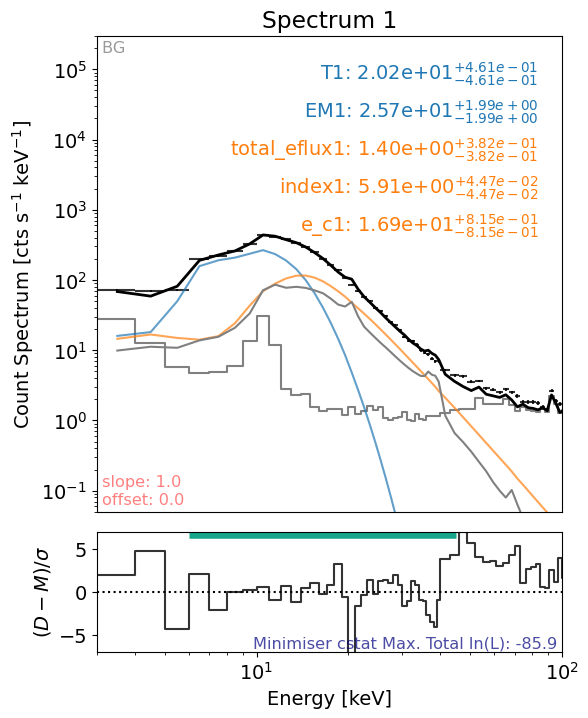

In [3]:
fdir = "fits/"
fspec="hsi_spectrum_20021005_0938_1114_3_250keV_alld.fits"
fsrm="hsi_srm_20021005_1040_1056_3_250keV_alld.fits"

ftims=Time(['2002-10-05T10:41:20.000','2002-10-05T10:42:24.000'],format='isot')
btims=Time(['2002-10-05T10:38:32.000','2002-10-05T10:40:32.000'],format='isot')

rhess_spec = RhessiLoader(spectrum_fn=fdir+fspec, srm_fn=fdir+fsrm)
rhess_spec.update_background_times(btims[0],btims[1])
rhess_spec.update_event_times(ftims[0],ftims[1])

fitter = Fitter(rhess_spec)
fitter.albedo_corr=True
# Flare at 382.7, -405.2 -> spex source angle 35.4919
fitter.albedo_angle=35.4919 * u.deg

fitter.model = "(f_vth+thick_fn)"
fitter.loglikelihood = "cstat"

# As A1 only fit > 6keV
fitter.energy_fitting_range = [6,15]
fitter.params["T1_spectrum1"] = {"Value":22, "Bounds":(10, 30)}
fitter.params["EM1_spectrum1"] = {"Value":10, "Bounds":(1e-1, 1e3)}
fitter.params["total_eflux1_spectrum1"] = {"Status":"fix", "Value":0.1, "Bounds":(1e-3, 1e2)}
fitter.params["index1_spectrum1"] = {"Status":"fix", "Value":6, "Bounds":(2, 12)}
fitter.params["e_c1_spectrum1"] = {"Status":"fix", "Value":20, "Bounds":(5, 30)}
spec_fit = fitter.fit()

# Then non-thermal fit higher energy
fitter.energy_fitting_range = [15,45]
fitter.params["T1_spectrum1"] = "fix"
fitter.params["EM1_spectrum1"] = "fix"
fitter.params["total_eflux1_spectrum1"] = "free"
fitter.params["index1_spectrum1"] = "free"
fitter.params["e_c1_spectrum1"] = "free"
spec_fit = fitter.fit()

# The do the full range
fitter.energy_fitting_range = [6,45]
fitter.params["T1_spectrum1"] = "free"
fitter.params["EM1_spectrum1"] = "free"
fitter.params["total_eflux1_spectrum1"] = "free"
fitter.params["index1_spectrum1"] = "free"
fitter.params["e_c1_spectrum1"] = "free"
spec_fit = fitter.fit()

xlims, ylims = [3,100], [5e-2,3e5]

plt.figure(figsize=(6,8))
axes, res_axes = fitter.plot()
for a in axes:
    a.set_xlim(xlims)
    a.set_ylim(ylims)
    a.set_xscale("log")
plt.show()

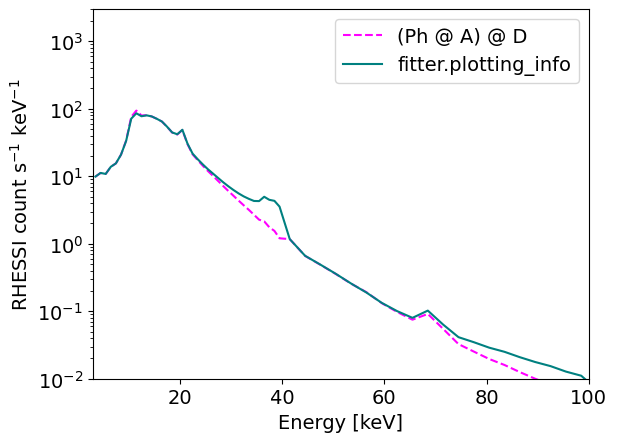

In [4]:
engs=fitter.plotting_info['spectrum1']['count_channels']
Eph = np.asarray(rhess_spec._loaded_spec_data['photon_channel_bins'])
D = np.asarray(rhess_spec._loaded_spec_data['srm'])
A = np.asarray(get_albedo_matrix(Eph * u.keV, fitter.albedo_angle, fitter.albedo_anisotropy))

# Get the total photon model - no albedo, just thermal + non-thermal
p = {n: float(v) for n, v in fitter.params.param_value.items()}
phi_total = np.asarray(
    fitter.model(
        p['T1_spectrum1'], p['EM1_spectrum1'],
        p['total_eflux1_spectrum1'], p['index1_spectrum1'], p['e_c1_spectrum1'],
        energies=Eph
    )
).ravel()

# Albedo count component from the fitter
fmd=fitter.plotting_info['spectrum1']['count_rate_model']
subsum = np.sum(np.vstack(fitter.plotting_info['spectrum1']['submodels']), axis=0)
bkg = fitter.plotting_info['spectrum1']['background_rate']
if len(bkg) == 2 * len(fmd):  # handle step-duplicated background arrays
    bkg = bkg[::2]
fal = fmd - subsum - bkg

# Calculate albedo count component
fal2=(phi_total @ A) @ D

plt.plot(engs,fal2,label='(Ph @ A) @ D',linestyle='dashed',color='magenta')
plt.plot(engs,fal,label='fitter.plotting_info',color='teal')
plt.ylabel(r'RHESSI count s$\mathit{^{-1}}$ keV$\mathit{^{-1}}$')
plt.xlabel('Energy [keV]')
plt.yscale('log')
xlim, ylim = [3,100], [1e-2,3e3]
plt.xlim(xlim)
plt.ylim(ylim)
plt.legend()
plt.show()

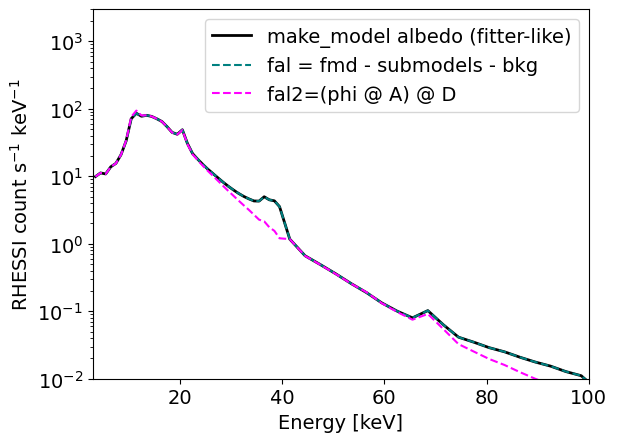

In [5]:
from sunkit_spex.legacy.fitting.fitter import make_model

# Reproduce fitter albedo count component using make_model()
photon_bin_widths = np.diff(Eph, axis=1).ravel()
count_bin_widths = np.asarray(rhess_spec._loaded_spec_data['count_channel_binning']).ravel()

# fitter._counts_model passes photon model multiplied by photon bin widths
photon_spec_binned = phi_total * photon_bin_widths

_, albedo_counts_per_s = make_model(
    energies=Eph,
    photon_model=photon_spec_binned,
    parameters=None,
    srm=D,
    albedo_corr=True,
    albedo_angle=fitter.albedo_angle,
    albedo_anisotropy=fitter.albedo_anisotropy,
 )

# fitter._calculate_model then divides by count bin widths for plotting units
fal_make = np.asarray(albedo_counts_per_s).ravel() / count_bin_widths

plt.plot(engs, fal_make, label='make_model albedo (fitter-like)', color='black', linewidth=2)
plt.plot(engs, fal, label='fal = fmd - submodels - bkg', color='teal',linestyle='dashed')
plt.plot(engs, fal2, label='fal2=(phi @ A) @ D', linestyle='dashed', color='magenta')
plt.ylabel(r'RHESSI count s$\mathit{^{-1}}$ keV$\mathit{^{-1}}$')
plt.xlabel('Energy [keV]')
plt.yscale('log')
plt.xlim([3,100])
plt.ylim([1e-2,3e3])
plt.legend()
plt.show()

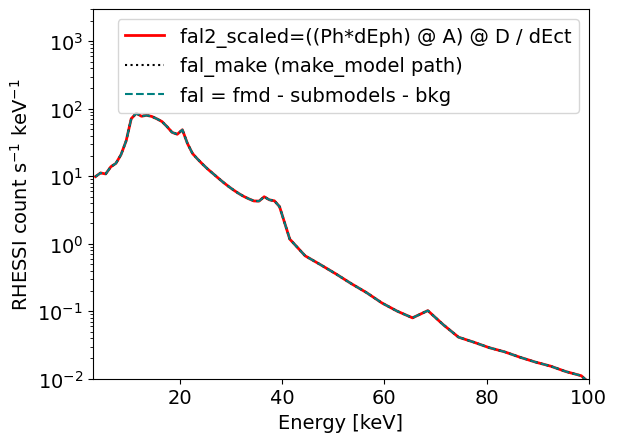

In [6]:
# Corrected direct-math albedo component (matches fitter units)
dEph = np.diff(Eph, axis=1).ravel()
dEct = np.asarray(rhess_spec._loaded_spec_data['count_channel_binning']).ravel()

# Equivalent to fitter flow: (phi*dEph -> albedo -> SRM fold) / dEct
fal2_scaled = ((phi_total * dEph) @ A) @ D / dEct

plt.plot(engs, fal2_scaled, label='fal2_scaled=((Ph*dEph) @ A) @ D / dEct', color='red', linewidth=2)
plt.plot(engs, fal_make, label='fal_make (make_model path)', color='black', linestyle='dotted')
plt.plot(engs, fal, label='fal = fmd - submodels - bkg', color='teal', linestyle='dashed')
plt.ylabel(r'RHESSI count s$\mathit{^{-1}}$ keV$\mathit{^{-1}}$')
plt.xlabel('Energy [keV]')
plt.yscale('log')
plt.xlim([3,100])
plt.ylim([1e-2,3e3])
plt.legend()
plt.show()

In [7]:
# Checking the SRM directly....
d = rhess_spec._loaded_spec_data
spec = d["spectrum1"] if "spectrum1" in d else d

srm = np.asarray(spec["srm"])                         # shape: (n_photon_bins, n_count_bins)
photon_bins = np.asarray(spec["photon_channel_bins"]) # shape: (n_photon_bins, 2)
count_bins = np.asarray(spec["count_channel_bins"])   # shape: (n_count_bins, 2)

dE_ph = np.asarray(spec["photon_channel_binning"]).ravel() # len n_photon_bins
dE_ct = np.asarray(spec["count_channel_binning"]).ravel()  # len n_count_bins

print("SRM shape:", srm.shape)
print("Photon bins:", photon_bins.shape, "Photon widths:", dE_ph.shape)
print("Count bins :", count_bins.shape,  "Count widths :", dE_ct.shape)

# print(photon_bins)
# print(count_bins)

SRM shape: (90, 77)
Photon bins: (90, 2) Photon widths: (90,)
Count bins : (77, 2) Count widths : (77,)


In [8]:
# # Load SRM FITS directly (no sunkit-spex) and inspect binning
# from astropy.io import fits
# import numpy as np

# srm_path = fdir + fsrm
# with fits.open(srm_path) as hdul:
#     print('Opened:', srm_path)
#     print('\nHDU summary:')
#     hdul.info()

#     # Show table columns so we can see where energy bins are stored
#     print('\nTable HDUs and columns:')
#     for i, hdu in enumerate(hdul):
#         cols = getattr(hdu, 'columns', None)
#         if cols is not None:
#             print(f'  HDU {i:2d} {hdu.name:>12s} -> {[c.name for c in cols]}')

#     # OGIP-style defaults usually present in RHESSI SRM files
#     matrix_hdu = hdul['MATRIX'] if 'MATRIX' in hdul else hdul[1]
#     ebounds_hdu = hdul['EBOUNDS'] if 'EBOUNDS' in hdul else hdul[2]

#     mdat = matrix_hdu.data
#     edat = ebounds_hdu.data

#     # Photon (true energy) bins: rows of SRM
#     e_lo = np.asarray(mdat['ENERG_LO'], dtype=float)
#     e_hi = np.asarray(mdat['ENERG_HI'], dtype=float)
#     photon_bins_fits = np.column_stack([e_lo, e_hi])
#     dE_ph_fits = e_hi - e_lo

#     # Count-channel bins: columns of SRM
#     c_lo = np.asarray(edat['E_MIN'], dtype=float)
#     c_hi = np.asarray(edat['E_MAX'], dtype=float)
#     count_bins_fits = np.column_stack([c_lo, c_hi])
#     dE_ct_fits = c_hi - c_lo

#     # SRM matrix itself
#     matrix_col = np.asarray(mdat['MATRIX'])
#     if matrix_col.ndim == 2:
#         srm_fits = matrix_col.astype(float)
#     else:
#         # Variable-length row vectors -> stack into 2D
#         srm_fits = np.vstack([np.asarray(r, dtype=float) for r in matrix_col])

# print('\nExtracted array shapes (from FITS):')
# print('  photon_bins_fits:', photon_bins_fits.shape)
# print('  count_bins_fits :', count_bins_fits.shape)
# print('  srm_fits        :', srm_fits.shape)
# print('  dE_ph_fits      :', dE_ph_fits.shape)
# print('  dE_ct_fits      :', dE_ct_fits.shape)

# # Quick consistency check: SRM rows/cols should match photon/count bins
# print('\nConsistency checks:')
# print('  rows == n_photon_bins:', srm_fits.shape[0] == photon_bins_fits.shape[0])
# print('  cols == n_count_bins :', srm_fits.shape[1] == count_bins_fits.shape[0])

# print('\nFirst 5 photon bins [keV]:')
# print(photon_bins_fits[:5])
# print('\nFirst 5 count bins [keV]:')
# print(count_bins_fits[:5])

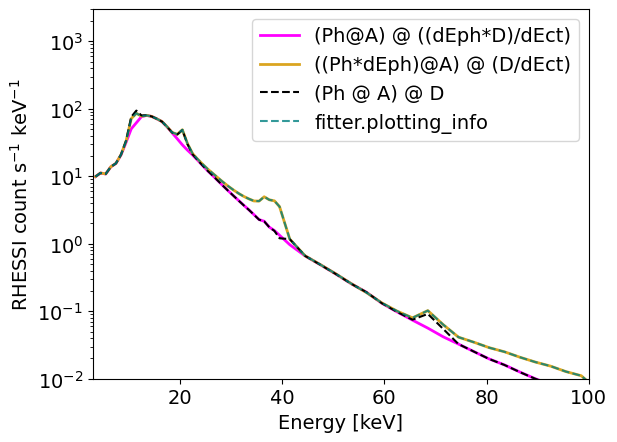

In [9]:
# Compare the two orderings explicitly
dEph = np.diff(Eph, axis=1).ravel()
dEct = np.asarray(rhess_spec._loaded_spec_data['count_channel_binning']).ravel()

# OSPEX-like pre-scaled response
D_ospex = (dEph[:, None] * D) / dEct[None, :]
fal_order_ospex = (phi_total @ A) @ D_ospex

# sunkit-spex fitter/make_model path
D_curr = D / dEct[None, :]
fal_order_curr = ((phi_total * dEph) @ A) @ D_curr

plt.plot(engs, fal_order_ospex, label='(Ph@A) @ ((dEph*D)/dEct)', color='fuchsia', linewidth=2)
plt.plot(engs, fal_order_curr, label='((Ph*dEph)@A) @ (D/dEct)', color='goldenrod', linewidth=2)
plt.plot(engs, fal2, label='(Ph @ A) @ D', linestyle='dashed', color='black')
plt.plot(engs, fal, label='fitter.plotting_info', color='teal', linestyle='--', alpha=0.8)
plt.ylabel(r'RHESSI count s$\mathit{^{-1}}$ keV$\mathit{^{-1}}$')
plt.xlabel('Energy [keV]')
plt.yscale('log')
plt.xlim([3,100])
plt.ylim([1e-2,3e3])
plt.legend()
plt.show()

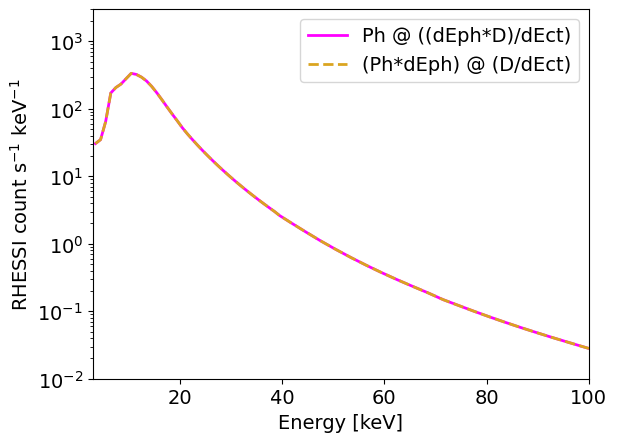

In [10]:
# Sanity check it works eitherway when not doing anything with the albedo

D_ospex = (dEph[:, None] * D) / dEct[None, :]
fmod_ospex = phi_total  @ D_ospex

D_curr = D / dEct[None, :]
fmod_curr = (phi_total * dEph) @ D_curr

plt.plot(engs, fmod_ospex, label='Ph @ ((dEph*D)/dEct)', color='fuchsia', linewidth=2)
plt.plot(engs, fmod_curr, label='(Ph*dEph) @ (D/dEct)', color='goldenrod', linewidth=2,linestyle='dashed')
plt.ylabel(r'RHESSI count s$\mathit{^{-1}}$ keV$\mathit{^{-1}}$')
plt.xlabel('Energy [keV]')
plt.yscale('log')
plt.xlim([3,100])
plt.ylim([1e-2,3e3])
plt.legend()
plt.show()

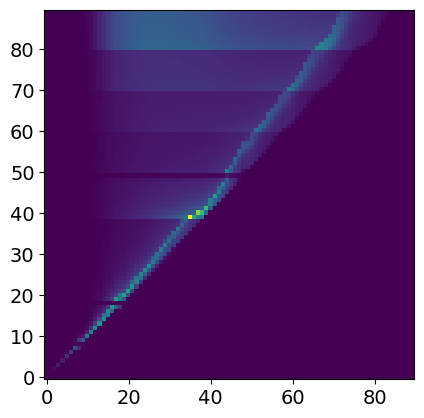

(90, 90)


In [11]:
plt.imshow(A, origin='lower')
plt.show()
print(A.shape)